In [2]:
# Question 4.1

x = [1,2,3,10]
y = [10, 20, 30, 40]

z1 = [x+y for x, y in zip(x,y)]

print(z1)

# One line

print([x+y for x, y in zip(x,y)])

# Using map()

def add(x, y):
    return x + y

plus = list(map(add, x, y))
print(plus)

[11, 22, 33, 50]
[11, 22, 33, 50]
[11, 22, 33, 50]


In [3]:
# Question 4.3

import numpy as np

move = input("Play either rock (R), paper (P) or scissors (S)")

responses = np.array(['R', 'P', 'S'])
countermove = np.random.choice(responses)
print(countermove)

if move == 'R':
    if countermove == 'R':
        print("Its a draw")
    elif countermove == 'P':
        print("You lose!")
    else:
        print("You win!")

if move == 'P':
    if countermove == 'P':
        print("Its a draw")
    elif countermove == 'S':
        print("You lose!")
    else:
        print("You win!")

if move == 'S':
    if countermove == 'S':
        print("Its a draw")
    elif countermove == 'R':
        print("You lose!")
    else:
        print("You win!")

Play either rock (R), paper (P) or scissors (S) S


R
You lose!


The mean: 184.99964072676963, the standard deviation: 8.014409460389215


Value of h: 5


Probability that X < 5.0 is 5.167056620250338e-112.
Probability of X within the range of one std of the mean is 0.6826894921370852


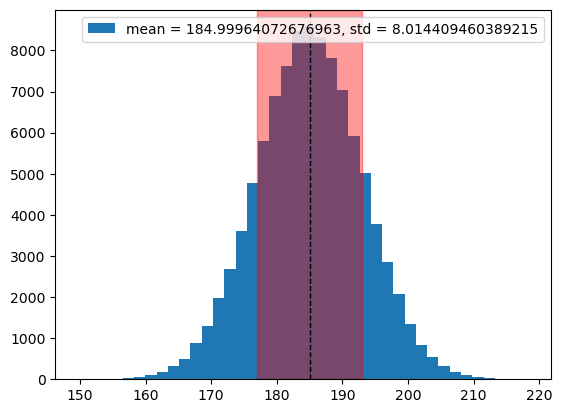

In [4]:
# Question 4.4

import numpy as np
import math
from matplotlib import pyplot as plt
import scipy

# Creating the normal distribution

length = np.random.normal(loc=185, scale=8, size=100000)

# Calculating the mean and standard diviation

mean = np.mean(length)
standv = np.std(length)
print(f"The mean: {mean}, the standard deviation: {standv}")

# Generating a histogram

plt.hist(length, bins=40, label = (f"mean = {mean}, std = {standv}"))
plt.legend()
plt.axvline(mean, color='k', linestyle='dashed', linewidth=1)
plt.axvspan(mean - standv, mean + standv, color = 'r', alpha = 0.4)

# Probabiloty X < h

h = float(input("Value of h:"))
cdf = scipy.stats.norm.cdf(h, mean, standv)
print(f"Probability that X < {h} is {cdf}.")

# Probability of X within the range of one std of the mean

cdf2 = scipy.stats.norm.cdf(mean + standv, mean, standv) - scipy.stats.norm.cdf(mean - standv, mean, standv)
print("Probability of X within the range of one std of the mean is", cdf2)

In [5]:
# Question 4.6

import numpy as np
from numpy import sin, cos, tan, log, log10
import math


fun = input("Enter a function f(x)=")
a = float(input("Lower bound:"))
b = float(input("Upper bound:"))
n = int(input("Number of data points:"))
x = np.random.uniform(a, b, n)
y = eval(fun)

int_ = ((b-a)/n)*np.sum(y)
print(f"The intergral of {fun} from {a} to {b} is {int_}")


Enter a function f(x)= 7
Lower bound: 7
Upper bound: 8
Number of data points: 8


The intergral of 7 from 7.0 to 8.0 is 0.875


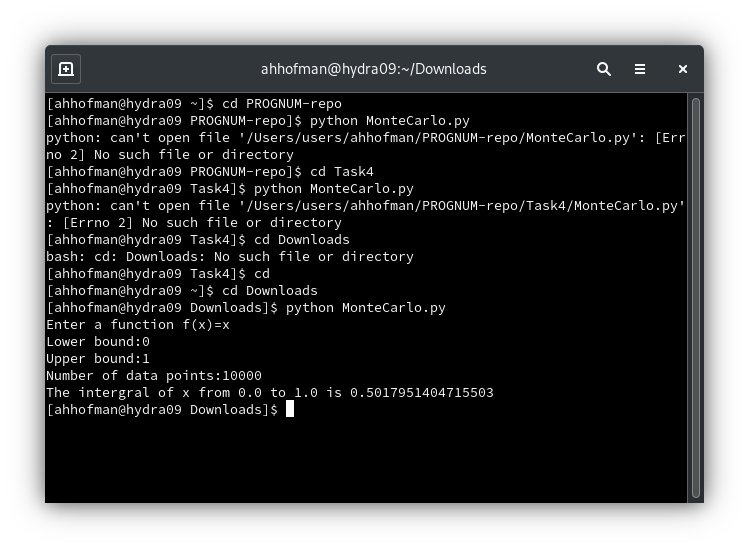

(0.8660254037844387+0.49999999999999994j) 1.0
[ 0.3660254   2.09807621  1.09807621 -0.6339746   0.3660254 ] [1.3660254  2.3660254  4.09807621 3.09807621 1.3660254 ]


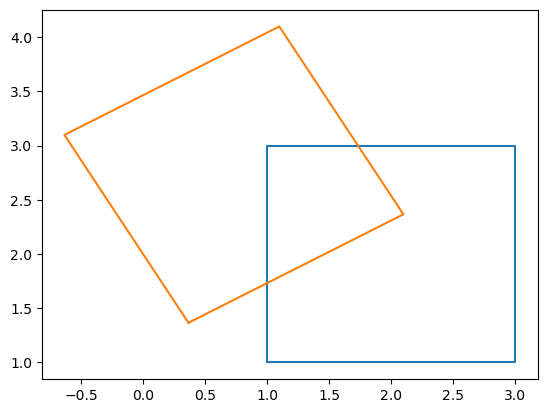

In [6]:
# Question 4.12

import math
from matplotlib import pyplot as plt
import numpy as np

# Creating a complex rotor for 30 degrees

angle_degs = 30  # Rotation angle
theta = math.radians(angle_degs)

rotor = math.cos(theta) + 1j*math.sin(theta)
print(rotor, abs(rotor))     # Proof that it has length 1

x = np.array([1,3,3,1,1])
y = np.array([1,1,3,3,1])

# Plotting the square

plt.plot(x,y)

# Rotaing the square

square = np.array([1 + 1j, 3 + 1j, 3 + 3j, 1 + 3j, 1 + 1j])
squarerotor = rotor * square

xnew = squarerotor.real
ynew = squarerotor.imag

print(xnew, ynew)

plt.plot(xnew,ynew)

In [7]:
# Question 4.14

import numpy as np

func = np.log10
seq = np.array([-100, -10, 0, 10, 100])


def funcfilter(func, seq):
    for i in range(len(seq)):
        if seq[i] > 0:
            print(func(seq[i]))
        
   
funcfilter(func, seq)


1.0
2.0


In [1]:
# Question 4.16

import math
from astropy.cosmology import Planck18
import scipy
from scipy import integrate

H0 = Planck18.H0.value 
Om0 = Planck18.Om0
Ode0 = Planck18.Ode0

z = float(input("z value:"))
def F(z):
    H = H0*math.sqrt(Om0*((1+z)**3)+Ode0)  # Value of H(z)
    fun = 1/((1+z)*H)  # intregral
    res = fun *  3.0857 * 10**19   # value in seconds
    res2 = res / (365*24*3600*(10**9))  # value in gigayears
    return res2

F(z)

print(scipy.integrate.quad(F, 0, z))


z value:2
(10.533489665393276, 1.6729642163547147e-12)


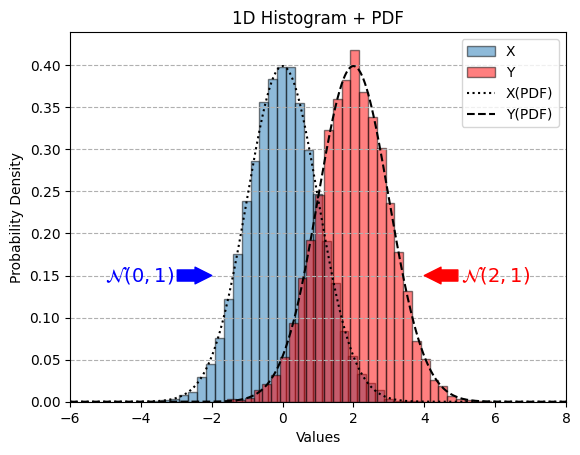

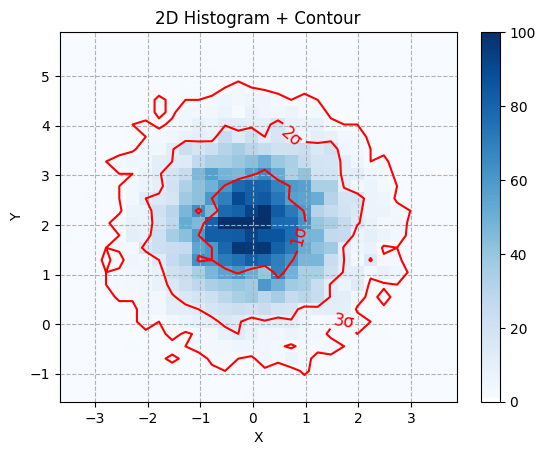

In [7]:
# Question 4.21

import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
from matplotlib.pyplot import subplots, show


X = np.random.normal(loc=0, scale=1, size=10000)
Y = np.random.normal(loc=2, scale=1, size=10000)

x = np.linspace(-6, 8, 1000)

# Plotting the histogram

fig,frame= subplots(1,1)
frame.hist(X, bins=30, alpha=0.5, label='X', edgecolor='black', density=True)
frame.hist(Y, bins=30, color='r', alpha=0.5, label='Y', edgecolor='black', density=True)

frame.plot(x, norm.pdf(x, 0, 1), color='black', label='X(PDF)', linestyle = ':')
frame.plot(x, norm.pdf(x, 2, 1), color='black', label='Y(PDF)', linestyle = '--')
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle = '--')
plt.xlabel("Values")
plt.ylabel("Probability Density")
plt.title("1D Histogram + PDF")
plt.xlim(-6,8)

# Arrows

plt.annotate(r'$\mathcal{N}(0,1)$',
             xy=(-2,0.15),
             xytext=(-5,0.15),
             fontsize=14,
             color='blue',
             va='center',
             arrowprops=dict(width=8, headwidth=12, color='blue'))

plt.annotate(r'$\mathcal{N}(2,1)$',
             xy=(4,0.15),
             xytext=(6,0.15),
             fontsize=14,
             color='red',
             va='center',
             ha='center',
             arrowprops=dict(width=8, headwidth=12, color='red'))
            
plt.show()

# 2D histogram

#Stuff for contour

H, xedges, yedges, im = plt.hist2d(X, Y, cmap='Blues',  bins=30)

xcenters = 0.5 * (xedges[:-1] + xedges[1:])
ycenters = 0.5 * (yedges[:-1] + yedges[1:])

Xgrid, Ygrid = np.meshgrid(xcenters, ycenters)
Z = H.T

# Normalize histogram to probability
Z = Z / np.sum(Z)

# Flatten and sort in descending order
Zflat = Z.flatten()
Zsort = np.sort(Zflat)[::-1]

# Cumulative sum
cumsum = np.cumsum(Zsort)

# Sigma probability targets (2D Gaussian)
probs = [0.393, 0.865, 0.989]

levels = []
for p in probs:
    idx = np.searchsorted(cumsum, p)
    levels.append(Zsort[idx])

levels = sorted(levels)

# Legend

ticks=np.array([0,20,40,60,80,100])

im.set_clim(1, 100)
cbar = plt.colorbar(im)
cbar.set_ticks(ticks)

# Plotting

CS = plt.contour(Xgrid, Ygrid, Z, levels=levels, colors='red')

# Contour labels

fmt = {
    levels[0]: "3σ",
    levels[1]: "2σ",
    levels[2]: "1σ"
}

plt.clabel(CS, CS.levels, fmt=fmt, inline=True, fontsize=12)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Histogram + Contour")
plt.grid(linestyle = '--')
plt.show()